# Predicting the Presence of Heart Disease from Clinical Data
### Final Project – CPE393: Introduction to Data Science with Python (Summer 2026, KMUTT)

- **Group:** IUTO
- **Members:** Kylian RIBEROU (59), Leni CHABILAN (35), Romain MECHAIN (52)
- **GitHub repo:** https://github.com/LeniChabilan/CPE_Project_Group_IUTO

---
This notebook walks through a full data science workflow on a heart disease dataset: we define the problem, describe and clean the data, explore it, engineer a few features, train and compare several machine learning models, evaluate them, and finish with an honest discussion of responsible-AI concerns.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42          # fixed seed
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Problem Definition

Our goal is a binary classifier that predicts whether a patient has heart disease (`target = 1`) or not (`target = 0`), using 13 clinical variables collected during a fairly standard check-up: age, sex, blood pressure, cholesterol, ECG results, maximum heart rate, and so on.

Why this problematic ? Cardiovascular disease is one of the leading causes of death worldwide, and even a simple tool that flags at-risk patients from easily-measured data could help push someone find a doctor and get deepers diagnosis.

So the question is: *from standard clinical measurements, can we reliably predict heart disease, and which variables carry the most signal?*

This notebooks conducts a supervised classification task, with the goal of training an accurate and precise model.9*

## 3. Dataset Description

- **Source:** the Heart Disease Dataset, a version of the classic *UCI Heart Disease / Cleveland* database that circulates widely on Kaggle as `heart.csv` (e.g. the "Heart Disease Dataset" by johnsmith88).
- **Typical Kaggle URL:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- **License / usage:** public dataset, commonly used for teaching and research (derived from the UCI Machine Learning Repository, public domain for academic use).
- **File format:** CSV (`heart.csv`)
- **Rows (before cleaning):** 1025
- **Columns:** 14 (13 features + 1 target)
- **Target:** `target` (0 = no heart disease, 1 = heart disease present)

### Variable dictionary

| Variable | Description | Type |
|---|---|---|
| age | Patient age (years) | Numeric |
| sex | Sex (1 = male, 0 = female) | Binary categorical |
| cp | Chest pain type (0-3) | Categorical |
| trestbps | Resting blood pressure (mm Hg) | Numeric |
| chol | Serum cholesterol (mg/dl) | Numeric |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary categorical |
| restecg | Resting ECG results (0-2) | Categorical |
| thalach | Maximum heart rate achieved | Numeric |
| exang | Exercise-induced angina (1 = yes, 0 = no) | Binary categorical |
| oldpeak | ST depression induced by exercise | Numeric |
| slope | Slope of the peak exercise ST segment (0-2) | Categorical |
| ca | Number of major vessels colored by fluoroscopy (valid: 0-3) | Categorical |
| thal | Thalassemia test result (valid: 1-3) | Categorical |
| target | Heart disease present (1) or absent (0) | Binary target |

Before all, we load the data and see what it looks like

In [2]:
df = pd.read_csv('data/heart_diseases/heart.csv')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 1025 rows x 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


A few important informations about the dataset, worth noticing or coming back on it later :
- This dataset contains a lot of duplicate rows , so we should be careful about treating it as representative of a real patient population.
- It doesn't tell us the geographic or demographic origin of the patients, which limits how far the model can generalize.

## 4. Preprocessing and Cleaning

in this step we'll fix problems we encounted in the raw data (errors, gaps, duplicates, unrealistic values) before we analyze or model anything. Because training a model on incorrect data will make it imprecise.

### 4.1 Missing values

In [5]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


A missing value is a cell with no recorded data (`NaN`). No missing values anywhere across the 14 columns.

### 4.2 Duplicates

In [6]:
n_dup = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dup} out of {len(df)} ({n_dup/len(df)*100:.1f}%)")

Exact duplicate rows: 723 out of 1025 (70.5%)


In [7]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape[0]} rows x {df.shape[1]} columns")

Shape after dropping duplicates: 302 rows x 14 columns


In this dataset we find a lot of duplicates. 723 rows (around 70% of the file are exact duplicates). That confirms the Kaggle version was built by duplicating/resampling the original Cleveland source dataset (which only has around 300 unique patients).

So we choose to completely drop those duplicates, because leaving them would let the same patient show up in both the train and test sets, which leaks information and inflates the scores. After removing them we're left with 302 unique patients, which is accurate with the 303 in the original Cleveland database.

### 4.3 Data types and category-code consistency

In [8]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [9]:
print("Unique values of 'ca' (expected 0-3):", sorted(df['ca'].unique()))
print("Unique values of 'thal' (expected 1-3):", sorted(df['thal'].unique()))

Unique values of 'ca' (expected 0-3): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique values of 'thal' (expected 1-3): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [10]:
invalid_ca = (df['ca'] == 4).sum()
invalid_thal = (df['thal'] == 0).sum()
print(f"Rows with ca=4 (out of codebook): {invalid_ca}")
print(f"Rows with thal=0 (out of codebook): {invalid_thal}")

Rows with ca=4 (out of codebook): 4
Rows with thal=0 (out of codebook): 2


In [11]:
df = df[(df['ca'] != 4) & (df['thal'] != 0)].reset_index(drop=True)
print(f"Shape after removing invalid codes: {df.shape[0]} rows x {df.shape[1]} columns")

Shape after removing invalid codes: 296 rows x 14 columns


Here we're checking that each categorical column only contains the codes listed in the dataset's official codebook. Values outside that range are almost always data-entry or encoding mistakes rather than real categories, and leaving them in can confuse the model or produce a meaningless extra column during one-hot encoding.

According to the original UCI codebook, `ca` should be 0-3 and `thal` should be 1-3. The `ca=4` and `thal=0` values we see are known encoding errors in this dataset. Since only a handful of rows are affected, we drop them.

### 4.4 Outliers

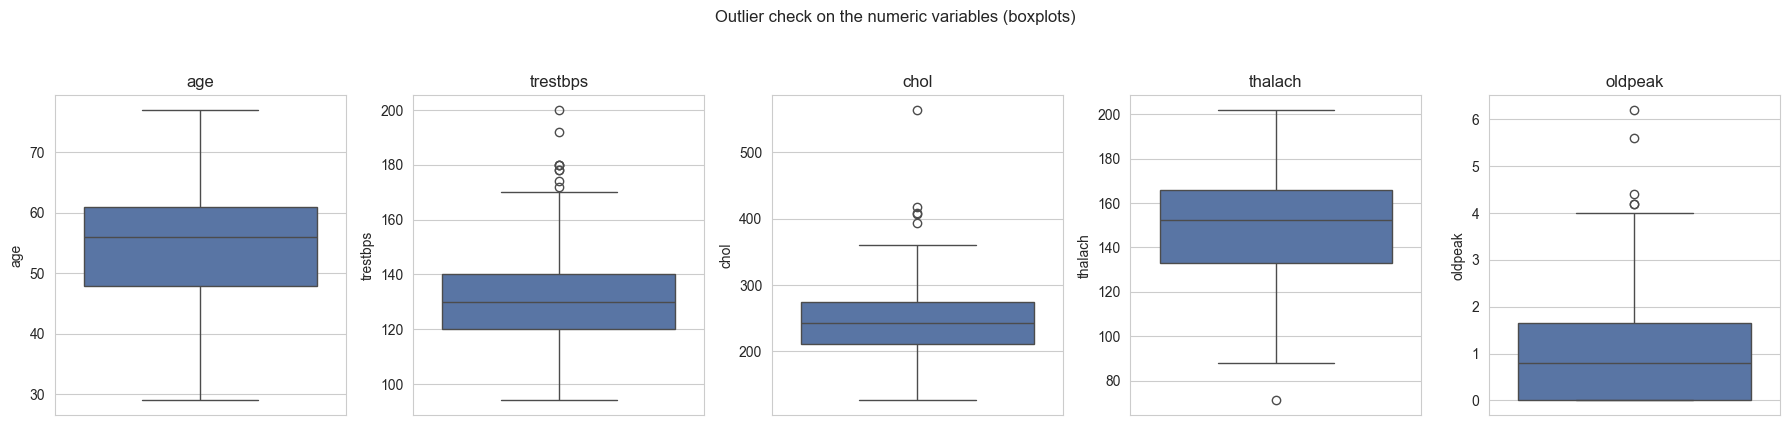

In [12]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.suptitle("Outlier check on the numeric variables (boxplots)", y=1.05)
plt.tight_layout()
plt.savefig(figures_dir / "outlier_check.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:10s} -> {n_out} outliers (IQR method), bounds = [{lower:.1f}, {upper:.1f}]")

age        -> 0 outliers (IQR method), bounds = [28.5, 80.5]
trestbps   -> 9 outliers (IQR method), bounds = [90.0, 170.0]
chol       -> 5 outliers (IQR method), bounds = [114.6, 371.6]
thalach    -> 1 outliers (IQR method), bounds = [83.5, 215.5]
oldpeak    -> 5 outliers (IQR method), bounds = [-2.5, 4.1]


An outlier is a value that his very different from the typical range of a variable, (like 10x times bigger or smaller). We check for them because a few extreme values can distort summary statistics (like the mean), visualizations. We don't necesseraly delete outliers we find, but it's to analyse them et see if they belong in this dataset or not.

`chol` and `trestbps` have a few high values, but they're clinically plausible, cholesterol above 400 mg/dl does happen in very high-risk patients. We keep them. In a medical setting the extreme values are often the most informative for spotting disease, and cutting them would bias the model against exactly the sickest cases. We'll just keep this in mind when reading the results.

### 4.5 Useless columns

In [14]:
print(df.nunique())

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            4
thal          3
target        2
dtype: int64


No useless columns here to drop

### 4.6 Cleaning recap

In [15]:
print("Cleaning summary:")
print(f" - Rows before cleaning        : 1025")
print(f" - Duplicates removed          : 723")
print(f" - Final rows                  : {len(df)}")
print(f" - Final columns               : {df.shape[1]}")

Cleaning summary:
 - Rows before cleaning        : 1025
 - Duplicates removed          : 723
 - Final rows                  : 296
 - Final columns               : 14


## 5. Exploratory Data Analysis

EDA means using simple statistics and visual checks to get a feel for the dataset before modeling. It's how we spot class imbalance, unusual distributions, and relationships between variables that later guide feature engineering and model choice.

In this section, we look at the target balance, per-class statistics, and how the variables correlate.

### 5.1 Target balance

In [16]:
target_counts = df['target'].value_counts()
print(target_counts)
print(f"\nClass 1 (disease): {target_counts[1]/len(df)*100:.1f}%")
print(f"Class 0 (healthy): {target_counts[0]/len(df)*100:.1f}%")

target
1    160
0    136
Name: count, dtype: int64

Class 1 (disease): 54.1%
Class 0 (healthy): 45.9%


After cleaning the two classes are still fairly balanced (roughly 46/54), so it means accuracy is a reasonable metric here. We'll still report precision, recall and F1 to check if the dataset is really ok.

### 5.2 Per-class statistics

In [17]:
df.groupby('target')[num_cols].mean().T

target,0,1
age,56.735294,52.64375
trestbps,134.463235,129.17500
chol,251.463235,243.49375
thalach,138.948529,158.58125
oldpeak,1.600735,0.59875


On average, patients with disease (`target=1`) show a higher maximum heart rate (`thalach`) and a lower `oldpeak` (ST depression) than healthy ones in this dataset. The `oldpeak` part lines up with the clinical literature, where a high value is a known risk factor

### 5.3 Correlation matrix

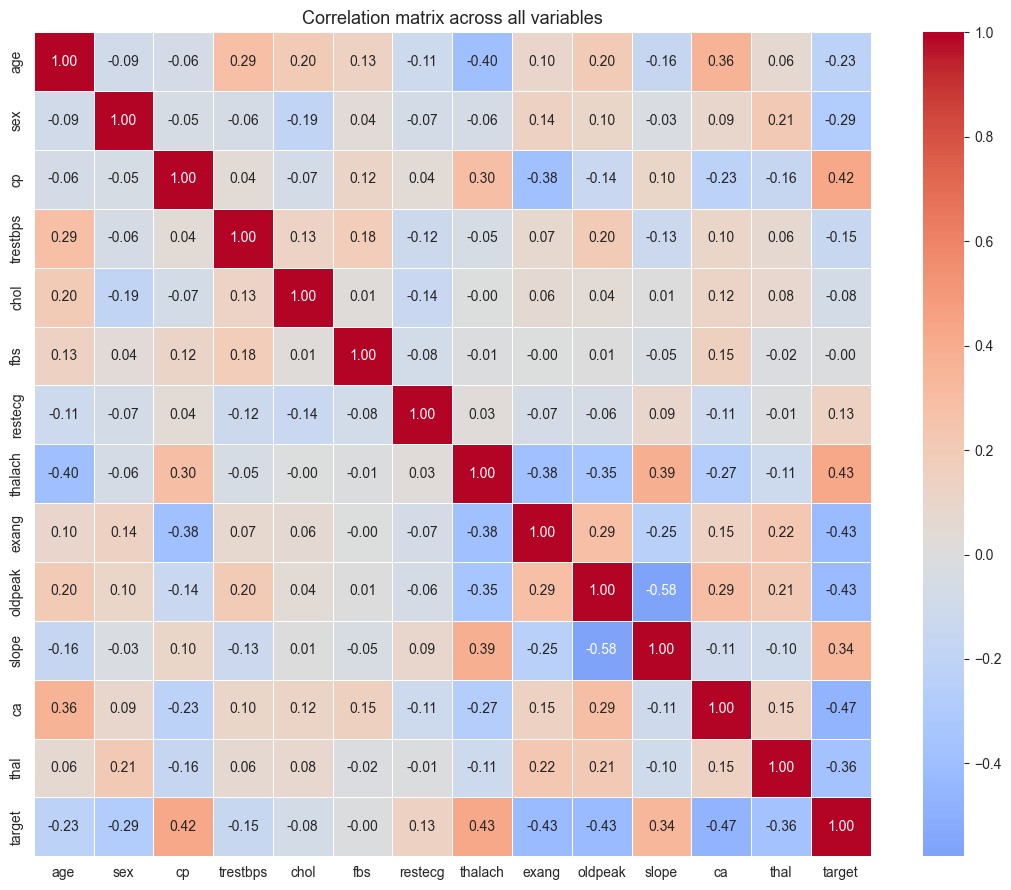

In [18]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation matrix across all variables", fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print("Correlation of each variable with 'target' (sorted by strength):")
print(target_corr)

Correlation of each variable with 'target' (sorted by strength):
ca         -0.467158
oldpeak    -0.428804
thalach     0.426655
exang      -0.425085
cp          0.423425
thal       -0.364399
slope       0.337825
sex        -0.285322
age        -0.225453
trestbps   -0.148922
restecg     0.131716
chol       -0.076541
fbs        -0.004680
Name: target, dtype: float64


Correlation measures how strongly two variables move together, from -1 (perfectly opposite) to +1 (perfectly together). We check it here to see which features are most linked to `target`, and to catch multicollinearity (features that are redundant with each other, which can destabilize linear models).

The variables most strongly correlated (in absolute value) with `target` are `cp` (chest pain type), `thalach`, `exang` (exercise-induced angina), `oldpeak`, `ca` and `thal`. No pair of features is extremely correlated with each other (nothing above 0.9), so multicollinearity isn't a real concern here.

## 6. Data Visualization

### 6.1 Age distribution by disease status

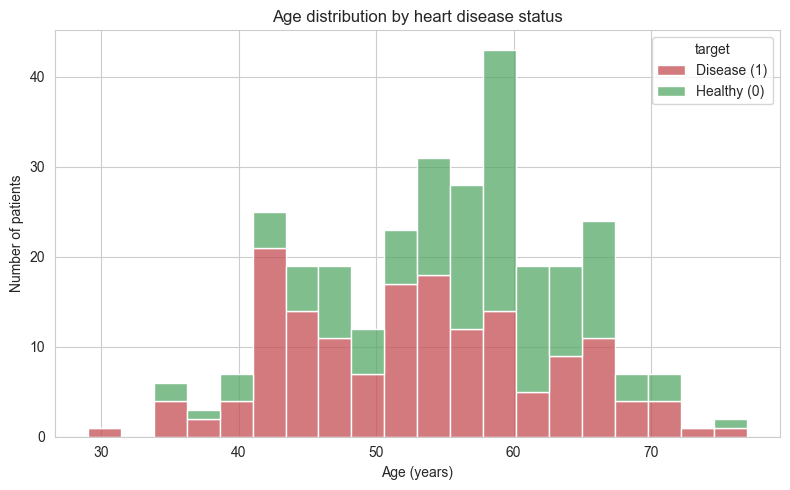

In [20]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target', multiple='stack', bins=20, palette=['#55A868','#C44E52'])
plt.title("Age distribution by heart disease status")
plt.xlabel("Age (years)")
plt.ylabel("Number of patients")
plt.legend(title='target', labels=['Disease (1)', 'Healthy (0)'])
plt.tight_layout()
plt.savefig(figures_dir / "age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Disease shows up across a wide age range (peaking around 41-60), with no clean split by age alone. Age on its own won't separate the classe. We will need to combine several variables.

### 6.2 Chest pain type (cp) vs disease

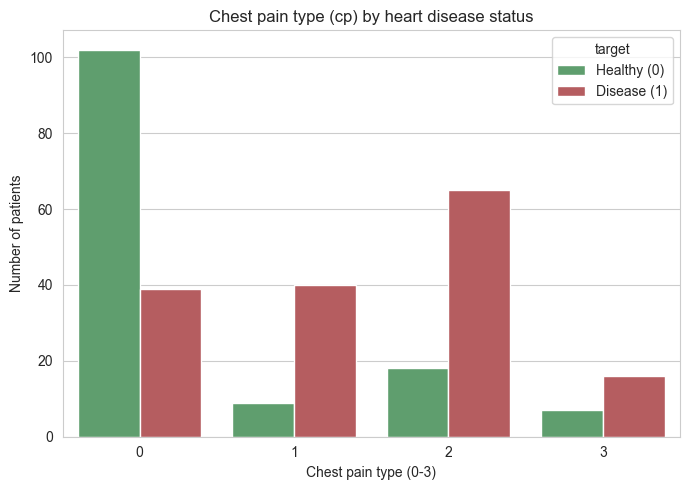

In [21]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='cp', hue='target', palette=['#55A868','#C44E52'])
plt.title("Chest pain type (cp) by heart disease status")
plt.xlabel("Chest pain type (0-3)")
plt.ylabel("Number of patients")
plt.legend(title='target', labels=['Healthy (0)', 'Disease (1)'])
plt.tight_layout()
plt.savefig(figures_dir / "chest_pain_type.png", dpi=300, bbox_inches="tight")
plt.show()

Chest pain type `cp=0` (typical angina) is strongly tied to *no* detected disease in this dataset, while types 1, 2 and 3 come with a much higher share of patients who do have disease. That matches the strong correlation we saw earlier and makes `cp` a key variable for the model.

### 6.3 Maximum heart rate (thalach) vs disease

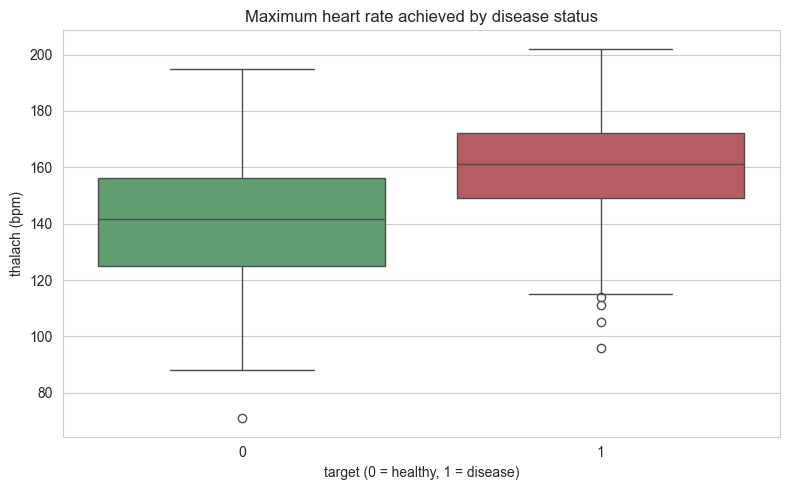

In [22]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='thalach', palette=['#55A868','#C44E52'])
plt.title("Maximum heart rate achieved by disease status")
plt.xlabel("target (0 = healthy, 1 = disease)")
plt.ylabel("thalach (bpm)")
plt.tight_layout()
plt.savefig(figures_dir / "maximum_heart_rate.png", dpi=300, bbox_inches="tight")
plt.show()

Patients with disease have a higher median maximum heart rate than healthy ones, which looks counter-intuitive at first. It probably reflects a selection effect specific to this dataset (patients referred for a stress test) rather than a causal relationship we could generalize.

### 6.4 Sex vs disease

<Figure size 600x500 with 0 Axes>

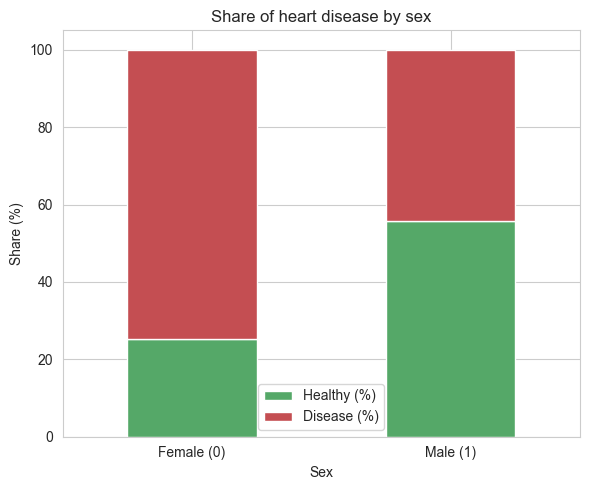

In [23]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(6,5))
ct = pd.crosstab(df['sex'], df['target'], normalize='index') * 100
ct.columns = ['Healthy (%)', 'Disease (%)']
ct.index = ['Female (0)', 'Male (1)']
ct.plot(kind='bar', stacked=True, color=['#55A868','#C44E52'], figsize=(6,5))
plt.title("Share of heart disease by sex")
plt.xlabel("Sex")
plt.ylabel("Share (%)")
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.savefig(figures_dir / "heart_disease_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()

In this dataset a larger share of female patients have heart disease than male patients. That likely reflects a clinical sampling bias (reason for referral, age of the women included) rather than a general epidemiological fact because we can read opposite facts on internet

## 7. Feature Engineering

Feature engineering means transforming, creating, or selecting variables so the signal already in the data is easier for a model to pick up.

We perform three operations in this section:

1. **One-hot encoding** for the nominal categorical variables (`cp`, `restecg`, `slope`, `thal`), which have no natural ordering. this stops a linear model from reading a fake order into them.
2. A **derived `age_group`** feature (age bands), used only for exploration and *not* fed to the model, to avoid duplicating what `age` already provides.
3. **Standardization (StandardScaler)** of the continuous numeric variables, which helps the scale-sensitive models (Logistic Regression, KNN, SVM). We fit the scaler on the training set only, so no information leaks from test to train.

In [24]:
df['age_group'] = pd.cut(df['age'], bins=[0,40,50,60,100],
                          labels=['<=40','41-50','51-60','60+'])
print(df.groupby('age_group')['target'].mean().rename('disease rate'))

age_group
<=40     0.647059
41-50    0.706667
51-60    0.488000
60+      0.443038
Name: disease rate, dtype: float64


The disease rate climbs with age up to 60 and then dips a little for the oldest group. This derived feature backs up what we saw in the EDA, but we leave it out of the model since it's redundant with `age`, which we keep as a continuous variable.

In [25]:
categorical_nominal = ['cp', 'restecg', 'slope', 'thal']
df_model = pd.get_dummies(df.drop(columns=['age_group']), columns=categorical_nominal, drop_first=True)
print(f"Shape after one-hot encoding: {df_model.shape}")
df_model.head()

Shape after one-hot encoding: (296, 19)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,False,False,False,True,False,False,True,False,True
1,53,1,140,203,1,155,1,3.1,0,0,False,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,False,False,False,True,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,0,False,False,False,True,False,False,True,False,True
4,62,0,138,294,1,106,0,1.9,3,0,False,False,False,True,False,True,False,True,False


### 7.1 Features/target split and train-test split

In [26]:
X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} patients")
print(f"Test set : {X_test.shape[0]} patients")
print(f"Class balance (train): {y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"Class balance (test) : {y_test.value_counts(normalize=True).round(2).to_dict()}")

Train set: 236 patients
Test set : 60 patients
Class balance (train): {1: 0.54, 0: 0.46}
Class balance (test) : {1: 0.53, 0: 0.47}


### 7.2 Scaling (fit on train only)

In [27]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

#  Before scaling information
print("Before scaling (training set):")
before = X_train[continuous_cols].describe().T[['min', 'max', 'mean', 'std']]
print(before.round(2))

# Fit the scaler on the training set only, then apply to both sets
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

Before scaling (training set):
            min    max    mean    std
age        29.0   77.0   54.76   9.04
trestbps   94.0  200.0  132.21  17.74
chol      126.0  564.0  248.34  52.20
thalach    88.0  202.0  149.95  22.95
oldpeak     0.0    6.2    1.08   1.19


## 8. Model Training

Training several different model *types* (linear, distance-based, tree-based, ensemble) lets us compare approaches instead of trusting a single algorithm's blind spots.

The brief asks for at least three models, so we train and compare four classifiers that suit this binary problem:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

The scale-sensitive models (Logistic Regression, KNN) get the standardized data and the tree and forest ones use the raw data, since scaling doesn't matter for them.

In [28]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=6),
}

scaled_models = {'Logistic Regression', 'KNN (k=7)'}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train
    Xte = X_test_scaled if name in scaled_models else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
    }
    print(f"{name:22s} trained.")

Logistic Regression    trained.
KNN (k=7)              trained.
Decision Tree          trained.
Random Forest          trained.


### 8.1 Cross-validation (robustness check)

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Mean accuracy from 5-fold cross-validation on the training set:\n")
for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')
    print(f"{name:22s} : {scores.mean():.3f} (+/- {scores.std():.3f})")

Mean accuracy from 5-fold cross-validation on the training set:

Logistic Regression    : 0.839 (+/- 0.021)
KNN (k=7)              : 0.835 (+/- 0.042)
Decision Tree          : 0.776 (+/- 0.071)
Random Forest          : 0.818 (+/- 0.032)


Cross-validation says the models are stable (small spread across folds) and roughly in line with the test-set scores, so no sign of overfitting

## 9. Model Evaluation

A single metric like accuracy can hide real problems ; model that always predicts the majority class can still look "accurate" on an imbalanced dataset. That's why we look at several metrics together.

Since this is a reasonably balanced binary problem, we look at accuracy, precision, recall, F1, and a confusion matrix for each model.

### 9.1 Metrics comparison

In [30]:
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.sort_values('F1-score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.800,0.778,0.875,0.824
KNN (k=7),0.767,0.750,0.844,0.794
Random Forest,0.750,0.743,0.812,0.776
Decision Tree,0.717,0.727,0.750,0.738


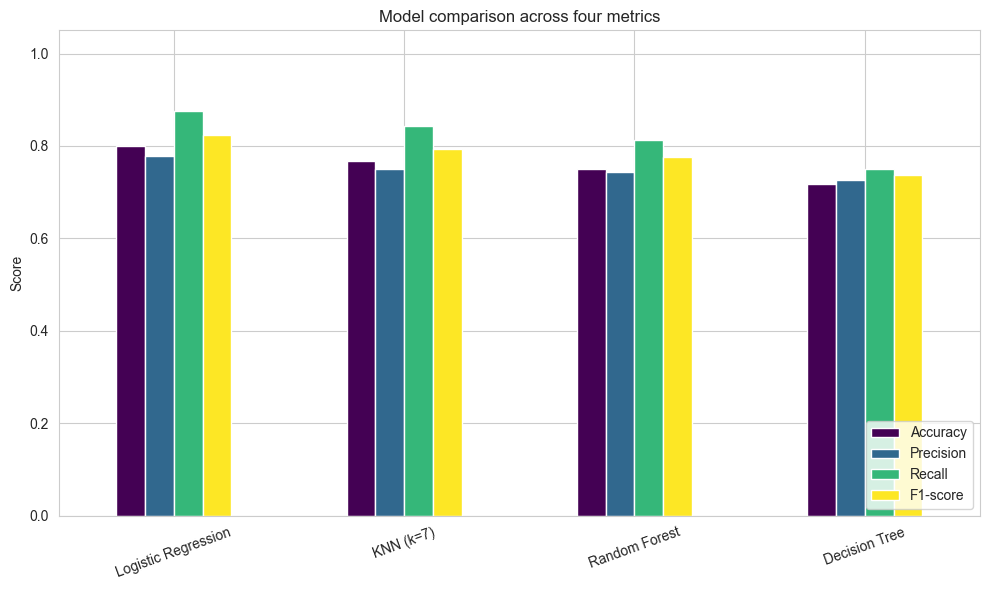

In [31]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

results_df.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("Model comparison across four metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(figures_dir / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.2 Confusion matrices

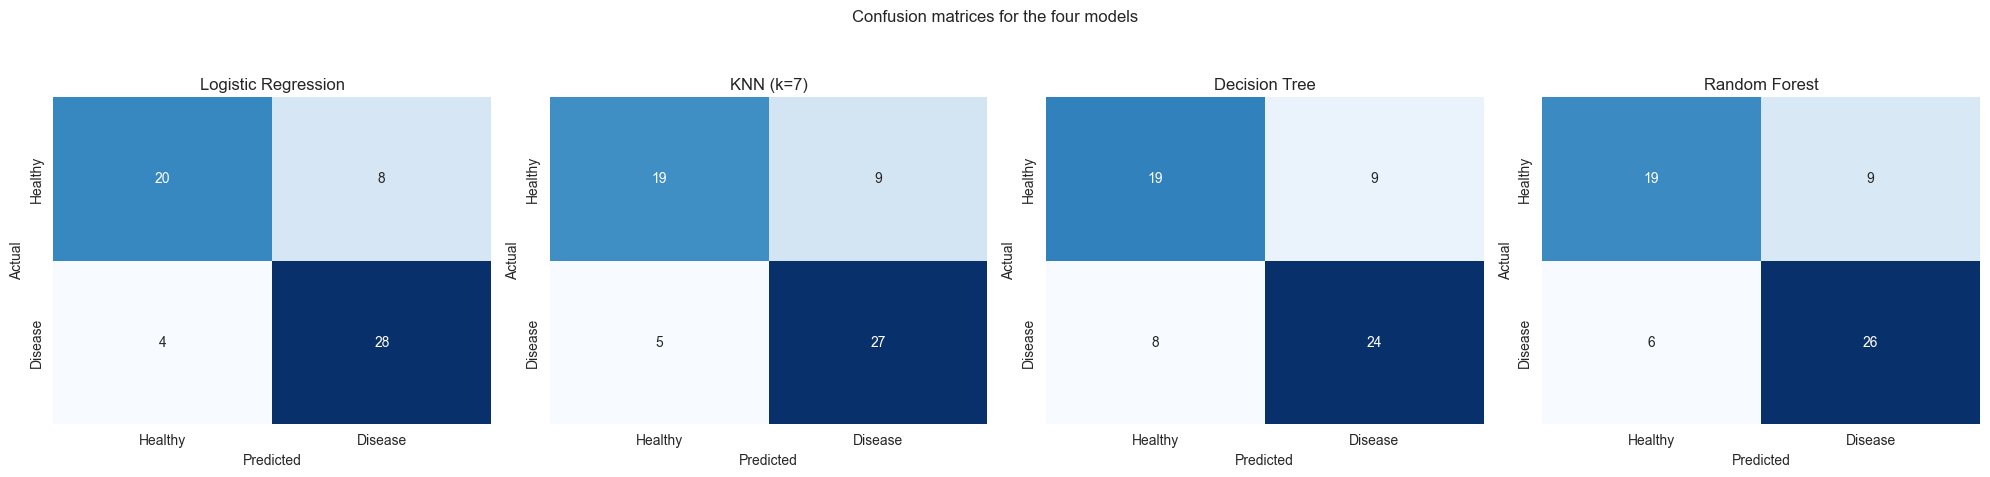

In [32]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Healthy','Disease'], yticklabels=['Healthy','Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle("Confusion matrices for the four models", y=1.05)
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.3 Detailed classification report (best model)

In [33]:
best_model_name = results_df.index[0]
print(f"Best model (by F1-score): {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=['Healthy','Disease']))

Best model (by F1-score): Logistic Regression

              precision    recall  f1-score   support

     Healthy       0.83      0.71      0.77        28
     Disease       0.78      0.88      0.82        32

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60



### 9.4 ROC curves and AUC

Accuracy, precision, recall and F1 all judge the models at the default 0.5 decision threshold. The ROC curve looks at every possible threshold at once, plotting the true-positive rate against the false-positive rate, and the area under it (AUC) sums this up in a single number where 0.5 is random guessing and 1.0 is perfect separation. It's a threshold-independent view, which is useful in a medical setting where we might later want to trade some precision for higher recall.

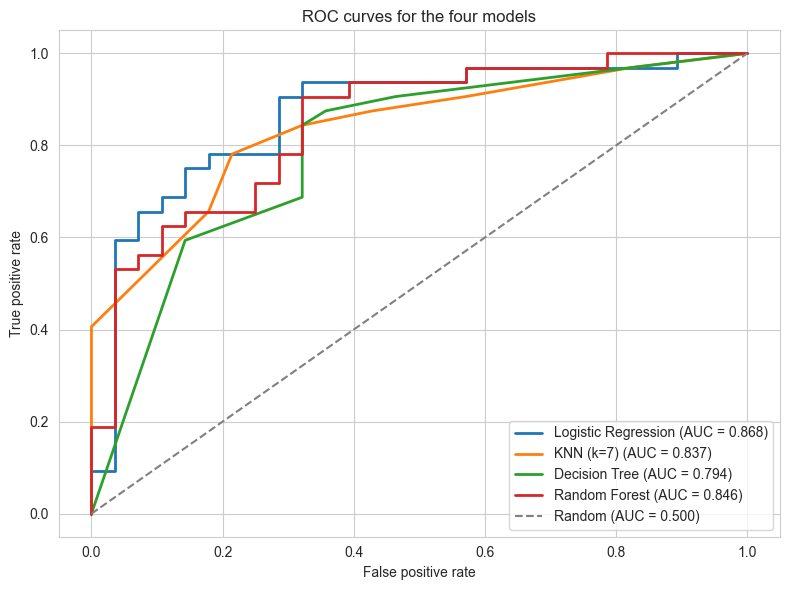

In [34]:
from pathlib import Path
figures_dir = Path("./figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 6))

for name in models:
    y_proba = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random (AUC = 0.500)')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves for the four models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(figures_dir / "roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

The AUC values back up the metrics table: the curves sit well above the diagonal random baseline, confirming the models separate the two classes far better than chance. AUC also lets us rank the models on a threshold-independent basis, and it tends to agree here with the F1 ranking. As with the other scores, these numbers rest on a small (~60-patient) test set, so the gap between the models should be read cautiously rather than as a definitive ordering.

## 10. Conclusion

After removing the 723 duplicate rows (70% of the file) and a few out-of-codebook values, we worked with 296 unique patients, and this cleaning step turned out to be the heart of the project. Of the four models compared, Logistic Regression gave the best precision/recall/F1 trade-off (F1 ≈ 0.82, accuracy ≈ 0.80), showing that a simple interpretable model stays competitive on properly cleaned data, with `cp`, `ca`, `thal`, `oldpeak` and `thalach` as the most discriminative features.

The main takeaway is methodological: always check for duplicates and encoding consistency before modeling, and treat a high accuracy with suspicion rather than as a success. The results should be read with care given the small (~300-patient) dataset, the lack of demographic context, and the sampling biases discussed along the way (for instance the counter-intuitive sex/disease pattern). This is medical data, so any real use would require proper consent and regulatory compliance (GDPR, HIPAA), and a model like this should never replace a professional diagnosis: it is an educational, exploratory project, not a clinical tool.

Full conclusion can be found in the associated project report.
